In [2]:
# Cell 0 — one-time setup (idempotent)
import sys, subprocess, importlib

def ensure(pkg, import_name=None):
    """Install pkg iff import fails."""
    name = import_name or pkg
    try:
        importlib.import_module(name)
        print(f"{pkg}: OK")
    except ImportError:
        print(f"{pkg}: installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", pkg])
        print(f"{pkg}: installed")

# Only installs if missing; safe to re-run
ensure("ipywidgets")
ensure("pyarrow")       # or comment out if you prefer fastparquet
# ensure("fastparquet") # alternative Parquet engine

print("Python interpreter:", sys.executable)

ipywidgets: OK
pyarrow: OK
Python interpreter: c:\Users\MY427UW\AppData\Local\Programs\Python\Python312\python.exe


In [3]:
import ipywidgets as widgets
widgets.IntSlider()

IntSlider(value=0)

In [4]:
%matplotlib inline

import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ipywidgets is optional; degrade gracefully if not present
try:
    import ipywidgets as widgets
    _HAS_WIDGETS = True
except Exception:
    widgets = None
    _HAS_WIDGETS = False
    print("ipywidgets not available; the interactive widget will be skipped.")

# Parquet engine detection (be explicit)
try:
    import pyarrow as _pa  # noqa
    _PARQUET_ENGINE = "pyarrow"
except Exception:
    try:
        import fastparquet  # noqa
        _PARQUET_ENGINE = "fastparquet"
    except Exception:
        _PARQUET_ENGINE = None
        print("No Parquet engine found. Install `pyarrow` (recommended) or `fastparquet`.")

In [5]:
# >>> EDIT THESE 3 LINES <<<
INPUT_PATH = r"C:\dev\amts\machine_learning\data\outputs\03_deciles_pipeline\train_df_woe.parquet"
TARGET_COL = "default_flag"       # set to your actual target column
DROP_COLS  = ["account_id","customer_id"]  # [] if no IDs to exclude

# Outputs go here (defaults to notebook folder)
OUTPUT_DIR = Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Reporting thresholds / limits
SALIENCE = 0.30           # show variables with at least one loading >= this
MAX_FACTORS_CAP = 15      # upper cap for auto-selection
PREFER_PARALLEL = True    # True: choose k via Parallel Analysis; False: Kaiser

In [6]:
def load_data(input_path: str | Path) -> pd.DataFrame:
    """Load CSV or Parquet into a DataFrame."""
    p = Path(input_path)
    if not p.exists():
        raise FileNotFoundError(f"Input not found: {p}")
    ext = p.suffix.lower()
    if ext == ".csv":
        return pd.read_csv(p)
    elif ext in (".parquet", ".pq"):
        if _PARQUET_ENGINE is None:
            raise RuntimeError("Install a Parquet engine: pip install pyarrow (or fastparquet)")
        return pd.read_parquet(p, engine=_PARQUET_ENGINE)
    else:
        raise ValueError(f"Unsupported file type: {ext}")

def _resolve_target_col(df: pd.DataFrame, preferred="default_flag") -> str:
    candidates = [preferred, "target", "bad_flag", "default", "label", "y", "Default"]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Target column not found. Checked: {candidates}")

def _ohe_compatible():
    """Return a OneHotEncoder that works across sklearn versions."""
    try:
        return OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    except TypeError:
        return OneHotEncoder(sparse=False, handle_unknown="ignore")

def preprocess_data(df: pd.DataFrame,
                    target_col: str = "default_flag",
                    drop_cols: list[str] | None = None):
    """
    Encodes categoricals, imputes missing values, scales features.
    Returns:
      X_scaled, y, encoder, categorical_cols, numerical_cols, features, corr_X
    """
    if target_col not in df.columns:
        target_col = _resolve_target_col(df, preferred=target_col)
        print(f"[info] Using detected target column: {target_col}")

    drop_cols = set(drop_cols or [])
    features = [c for c in df.columns if c not in drop_cols and c != target_col]

    categorical_cols = df[features].select_dtypes(include=["object", "category"]).columns.tolist()
    numerical_cols   = df[features].select_dtypes(exclude=["object", "category"]).columns.tolist()

    encoder = _ohe_compatible()
    X_cat = encoder.fit_transform(df[categorical_cols]) if categorical_cols else np.empty((len(df), 0))
    X_num = df[numerical_cols].to_numpy() if numerical_cols else np.empty((len(df), 0))
    X_all = np.hstack([X_num, X_cat])

    imputer   = SimpleImputer(strategy="mean")
    X_imputed = imputer.fit_transform(X_all)
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(X_imputed)

    y_raw = df[target_col]
    y = y_raw.to_numpy() if y_raw.dtype.kind in "biufc" else pd.factorize(y_raw)[0]

    # correlation of standardized features (≈ correlation matrix)
    corr_X = np.corrcoef(X_scaled, rowvar=False)

    return X_scaled, y, encoder, categorical_cols, numerical_cols, features, corr_X


In [7]:
def plot_pca_2d(X_scaled, y):
    pca_2d = PCA(n_components=2)
    X_p2 = pca_2d.fit_transform(X_scaled)
    plt.figure(figsize=(8,6))
    sc = plt.scatter(X_p2[:,0], X_p2[:,1], c=y, cmap='viridis', alpha=0.7)
    plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('2D PCA')
    plt.colorbar(sc, label='Target'); plt.tight_layout(); plt.show()
    return pca_2d, X_p2

def plot_pca_3d(X_scaled, y):
    pca_3d = PCA(n_components=3)
    X_p3 = pca_3d.fit_transform(X_scaled)
    fig = plt.figure(figsize=(10,8))
    ax = fig.add_subplot(111, projection='3d')
    uniq = np.unique(y)
    if len(uniq) <= 10:
        colors = ['red','blue','green','orange','purple','brown','pink','gray','olive','cyan']
        cmap = ListedColormap(colors[:len(uniq)])
        sc = ax.scatter(X_p3[:,0], X_p3[:,1], X_p3[:,2], c=y, cmap=cmap, alpha=0.7)
        handles = [plt.Line2D([0],[0], marker='o', color='w', label=str(c),
                              markerfacecolor=colors[i], markersize=10)
                   for i,c in enumerate(uniq)]
        ax.legend(handles=handles, title='Target', loc='best')
    else:
        sc = ax.scatter(X_p3[:,0], X_p3[:,1], X_p3[:,2], c=y, cmap='viridis', alpha=0.7)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    ax.set_title('3D PCA'); plt.tight_layout(); plt.show()
    return pca_3d, X_p3

def print_pca_feature_weights(pca, encoder, categorical_cols, numerical_cols, title, n_top=10):
    cat_names = encoder.get_feature_names_out(categorical_cols) if categorical_cols else np.array([])
    all_names = numerical_cols + list(cat_names)
    print(title)
    for i, comp in enumerate(pca.components_):
        print(f"\nComponent {i+1}:")
        for idx in np.argsort(np.abs(comp))[::-1][:n_top]:
            print(f"  {all_names[idx]}: {comp[idx]:.4f}")

def plot_feature_scatter(df, feature_names, y):
    if not _HAS_WIDGETS:
        print("Install ipywidgets to enable the interactive scatter.")
        return
    f1 = widgets.Dropdown(options=feature_names, description='Feature 1:')
    f2 = widgets.Dropdown(options=feature_names, description='Feature 2:')
    btn = widgets.Button(description="Plot")
    out = widgets.Output()
    def on_click(_):
        with out:
            out.clear_output()
            plt.figure(figsize=(8,6))
            plt.scatter(df[f1.value], df[f2.value], c=y, cmap='viridis', alpha=0.7)
            plt.xlabel(f1.value); plt.ylabel(f2.value)
            plt.title(f'{f1.value} vs {f2.value}')
            plt.colorbar(label='Target'); plt.tight_layout(); plt.show()
    btn.on_click(on_click)
    display(widgets.VBox([f1, f2, btn, out]))

In [8]:
def choose_n_factors_kaiser(X_scaled, plot=True, max_factors=None):
    pca_full = PCA()
    pca_full.fit(X_scaled)
    eig = pca_full.explained_variance_

    if plot:
        xs = np.arange(1, len(eig)+1)
        plt.figure(figsize=(9,4.5))
        plt.plot(xs, eig, marker='o')
        plt.axhline(1.0, linestyle='--', label='Kaiser=1')
        plt.title('Scree Plot (PCA eigenvalues)')
        plt.xlabel('Component'); plt.ylabel('Eigenvalue')
        plt.legend(); plt.tight_layout(); plt.show()

    k = max(1, int(np.sum(eig > 1.0)))
    if max_factors is not None:
        k = min(k, int(max_factors))
    return k, eig

def varimax(Phi, gamma=1.0, q=20, tol=1e-6):
    p, k = Phi.shape
    R = np.eye(k); d = 0
    for _ in range(q):
        d_old = d
        Lambda = Phi @ R
        u, s, vh = np.linalg.svd(Phi.T @ (Lambda**3 - (gamma/p) * (Lambda @ np.diag(np.sum(Lambda**2, axis=0)))))
        R = u @ vh
        d = np.sum(s)
        if d_old and d/d_old < 1 + tol:
            break
    return Phi @ R, R

def parallel_analysis(X, n_iter=200, seed=0):
    """95th percentile null eigenvalues from random normal data."""
    n, p = X.shape
    real = PCA().fit(X).explained_variance_
    rng = np.random.default_rng(seed)
    null_eigs = np.zeros((n_iter, p))
    for i in range(n_iter):
        Z = rng.standard_normal(size=(n,p))
        Z = (Z - Z.mean(0)) / Z.std(0, ddof=1)
        null_eigs[i] = PCA().fit(Z).explained_variance_
    perc95 = np.percentile(null_eigs, 95, axis=0)
    k_pa = int(np.sum(real > perc95))
    xs = np.arange(1, p+1)
    plt.figure(figsize=(9,4.5))
    plt.plot(xs, real, marker='o', label='Observed')
    plt.plot(xs, perc95, linestyle='--', label='PA 95%')
    plt.axhline(1.0, linestyle=':', label='Kaiser=1')
    plt.title('Scree + Parallel Analysis')
    plt.xlabel('Component'); plt.ylabel('Eigenvalue'); plt.legend(); plt.tight_layout(); plt.show()
    return k_pa, real, perc95

def fa_cv_loglike(X, ks=(1,2,3,4,5), n_splits=5, max_iter=3000, tol=1e-4, seed=0):
    """Cross-validated average log-likelihood per sample by k."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []
    for k in ks:
        ll = []
        for tr, te in kf.split(X):
            fa = FactorAnalysis(n_components=k, max_iter=max_iter, tol=tol, random_state=seed)
            fa.fit(X[tr])
            ll.append(fa.score(X[te]))
        rows.append((k, float(np.mean(ll)), float(np.std(ll))))
    df = pd.DataFrame(rows, columns=['k','mean_loglike','std'])
    return df.sort_values('k')

In [9]:
# --- FAST FACTOR ANALYSIS: fit on a subsample, then score all rows ---

def run_factor_analysis(X_scaled,
                        corr_X,
                        encoder,
                        categorical_cols,
                        numerical_cols,
                        n_factors=None,
                        rotate=True,
                        max_factors_cap=15,
                        align_to_target=None,
                        y=None,
                        row_subsample=30000,     # fit FA on at most this many rows
                        random_state=0,
                        max_iter=1500,           # speed-first
                        tol=1e-3):               # speed-first
    """
    Fits Factor Analysis on a row subsample for speed, optionally varimax-rotates,
    aligns factor signs to the target if requested, then computes scores for ALL rows.
    Saves loadings/communalities/scores to CSV. Also reports RMSR vs reproduced corr.
    """
    rng = np.random.default_rng(random_state)
    n, p = X_scaled.shape

    # feature names
    cat_names = encoder.get_feature_names_out(categorical_cols) if categorical_cols else np.array([])
    all_names = numerical_cols + list(cat_names)

    # choose k if not provided (cheap Kaiser)
    if n_factors is None:
        kaiser_k, _ = choose_n_factors_kaiser(X_scaled, plot=False, max_factors=max_factors_cap)
        n_factors = kaiser_k
        print(f"[FA] Auto-selected k (Kaiser): {n_factors}")

    # subsample rows for fitting if large
    X_fit = X_scaled
    if row_subsample and n > row_subsample:
        idx = rng.choice(n, row_subsample, replace=False)
        X_fit = X_scaled[idx]
        print(f"[FA] Fitting on subsample {row_subsample:,}/{n:,} rows for speed; "
              f"will score ALL rows after fitting.")

    # fit FA
    fa = FactorAnalysis(n_components=n_factors,
                        random_state=random_state,
                        max_iter=max_iter,
                        tol=tol)
    fa.fit(X_fit)

    # loadings & scores
    loadings = fa.components_.T
    if rotate:
        loadings, R = varimax(loadings)
        scores_all = fa.transform(X_scaled) @ R
        print("[FA] Applied varimax rotation.")
    else:
        scores_all = fa.transform(X_scaled)

    # optional sign alignment toward risk
    if align_to_target and y is not None:
        for j in range(loadings.shape[1]):
            if np.corrcoef(scores_all[:, j], y)[0, 1] < 0:
                scores_all[:, j] *= -1
                loadings[:, j]  *= -1
        print("[FA] Aligned factor signs so corr(score, target) >= 0.")

    communalities = np.sum(loadings**2, axis=1)
    uniquenesses  = np.clip(1.0 - communalities, 0.0, None)

    fac_labels = [f"F{i+1}" for i in range(n_factors)]
    load_df   = pd.DataFrame(loadings, index=all_names, columns=fac_labels)
    comm_df   = pd.DataFrame({"feature": all_names,
                              "communality": communalities,
                              "uniqueness": uniquenesses}).set_index("feature")
    scores_df = pd.DataFrame(scores_all, columns=fac_labels)

    R_hat = loadings @ loadings.T + np.diag(uniquenesses)
    rmsr = float(np.sqrt(((corr_X - R_hat)**2).mean()))
    mean_comm = float(communalities.mean())

    SALIENCE = 0.30
    tidy = (load_df[load_df.abs().max(1) >= SALIENCE]
            .join(comm_df, how="left")
            .sort_values("communality", ascending=False))

    load_df.to_csv(OUTPUT_DIR / "factor_loadings.csv")
    comm_df.to_csv(OUTPUT_DIR / "factor_communalities.csv")
    scores_df.to_csv(OUTPUT_DIR / "factor_scores.csv")
    tidy.to_csv(OUTPUT_DIR / "factor_loadings_tidy.csv")

    print(f"\nSaved: {OUTPUT_DIR/'factor_loadings.csv'}, "
          f"{OUTPUT_DIR/'factor_communalities.csv'}, {OUTPUT_DIR/'factor_scores.csv'}")
    print(f"Also: {OUTPUT_DIR/'factor_loadings_tidy.csv'}")
    print(f"Mean communality: {mean_comm:.3f} | RMSR: {rmsr:.3f}")

    for j, f in enumerate(fac_labels):
        print(f"\nTop loadings for {f}:")
        top_idx = np.argsort(np.abs(loadings[:, j]))[::-1][:10]
        for idx in top_idx:
            print(f"  {all_names[idx]}: {loadings[idx, j]:.4f}")

    return {
        "fa": fa,
        "n_factors": n_factors,
        "loadings_df": load_df,
        "communities_df": comm_df if 'communities_df' in locals() else None,  # backward compat
        "communalities_df": comm_df,
        "scores_df": scores_df,
        "tidy_loadings": tidy,
        "rmsr": rmsr,
        "mean_communalities": mean_comm
    }


In [10]:
def run(input_path: str | Path,
        target_col: str = "default_flag",
        drop_cols: list[str] | None = None,
        n_factors: int | None = None,
        prefer_parallel: bool = True,
        align_factors_to_target: bool = True):
    """
    1) Load & preprocess
    2) PCA 2D/3D + feature weights
    3) Scree + Parallel Analysis
    4) Factor Analysis (varimax, high max_iter), optional sign alignment toward risk
    5) Save CSV outputs & return handles
    """
    print(f"Loading: {input_path}")
    df = load_data(input_path)

    X_scaled, y, enc, cat_cols, num_cols, features, corr_X = preprocess_data(
        df, target_col=target_col, drop_cols=drop_cols
    )

    # PCA
    pca_2d, X_p2 = plot_pca_2d(X_scaled, y)
    print("Explained variance ratio (2D):", pca_2d.explained_variance_ratio_)
    pd.DataFrame(X_p2, columns=["PC1","PC2"]).to_csv(OUTPUT_DIR / "pca_2d_output.csv", index=False)

    pca_3d, X_p3 = plot_pca_3d(X_scaled, y)
    print("Explained variance ratio (3D):", pca_3d.explained_variance_ratio_)
    pd.DataFrame(X_p3, columns=["PC1","PC2","PC3"]).to_csv(OUTPUT_DIR / "pca_3d_output.csv", index=False)

    print('\nTop features (PCA 2D):'); print_pca_feature_weights(pca_2d, enc, cat_cols, num_cols, title="", n_top=10)
    print('\nTop features (PCA 3D):'); print_pca_feature_weights(pca_3d, enc, cat_cols, num_cols, title="", n_top=10)

    # Scree + PA
    k_kaiser, eig = choose_n_factors_kaiser(X_scaled, plot=True, max_factors=MAX_FACTORS_CAP)
    k_pa, _, _ = parallel_analysis(X_scaled, n_iter=200, seed=0)
    k_chosen = (k_pa if prefer_parallel else k_kaiser) if n_factors is None else n_factors
    print(f"\nSuggested k — Kaiser: {k_kaiser} | Parallel Analysis: {k_pa} | Using k: {k_chosen}")

    print('\nInteractive scatter (if ipywidgets installed):')
    plot_feature_scatter(df, features, y)

    # Factor Analysis
    print("\n=== Running Factor Analysis ===")
    fa_results = run_factor_analysis(
        X_scaled=X_scaled,
        corr_X=corr_X,
        encoder=enc,
        categorical_cols=cat_cols,
        numerical_cols=num_cols,
        n_factors=k_chosen,
        rotate=True,
        max_factors_cap=MAX_FACTORS_CAP,
        align_to_target=align_factors_to_target,
        y=y
    )

    return {
        "df": df,
        "X_scaled": X_scaled,
        "y": y,
        "pca_2d": pca_2d,
        "pca_3d": pca_3d,
        "fa": fa_results["fa"],
        "factor_loadings": fa_results["loadings_df"],
        "factor_communalities": fa_results["communalities_df"],
        "factor_scores": fa_results["scores_df"],
        "tidy_loadings": fa_results["tidy_loadings"],
        "rmsr": fa_results["rmsr"],
        "mean_communalities": fa_results["mean_communalities"],
        "k_suggested_kaiser": k_kaiser,
        "k_suggested_PA": k_pa,
        "k_used": k_chosen
    }

In [11]:
# speed knobs for Parallel Analysis (only used if prefer_parallel=True)
PA_N_ITER   = 30          # was 200; big speed-up
PA_MAX_ROWS = 20000       # subsample rows for PA if dataset is huge

def run(input_path: str | Path,
        target_col: str = "default_flag",
        drop_cols: list[str] | None = None,
        n_factors: int | None = None,
        prefer_parallel: bool = True,
        align_factors_to_target: bool = True):
    print(f"Loading: {input_path}")
    df = load_data(input_path)

    X_scaled, y, enc, cat_cols, num_cols, features, corr_X = preprocess_data(
        df, target_col=target_col, drop_cols=drop_cols
    )

    # PCA
    pca_2d, X_p2 = plot_pca_2d(X_scaled, y)
    print("Explained variance ratio (2D):", pca_2d.explained_variance_ratio_)
    pd.DataFrame(X_p2, columns=["PC1","PC2"]).to_csv(OUTPUT_DIR / "pca_2d_output.csv", index=False)

    pca_3d, X_p3 = plot_pca_3d(X_scaled, y)
    print("Explained variance ratio (3D):", pca_3d.explained_variance_ratio_)
    pd.DataFrame(X_p3, columns=["PC1","PC2","PC3"]).to_csv(OUTPUT_DIR / "pca_3d_output.csv", index=False)

    print('\nTop features (PCA 2D):'); print_pca_feature_weights(pca_2d, enc, cat_cols, num_cols, title="", n_top=10)
    print('\nTop features (PCA 3D):'); print_pca_feature_weights(pca_3d, enc, cat_cols, num_cols, title="", n_top=10)

    # Kaiser (cheap)
    k_kaiser, _ = choose_n_factors_kaiser(X_scaled, plot=True, max_factors=MAX_FACTORS_CAP)

    # Parallel Analysis — only if requested
    k_pa = None
    if prefer_parallel:
        X_for_pa = X_scaled
        if X_scaled.shape[0] > PA_MAX_ROWS:
            idx = np.random.default_rng(0).choice(X_scaled.shape[0], PA_MAX_ROWS, replace=False)
            X_for_pa = X_scaled[idx]
        k_pa, _, _ = parallel_analysis(X_for_pa, n_iter=PA_N_ITER, seed=0)

    k_chosen = (k_pa if (prefer_parallel and k_pa is not None) else k_kaiser) if n_factors is None else n_factors
    print(f"\nSuggested k — Kaiser: {k_kaiser} | PA: {k_pa} | Using k: {k_chosen}")

    print('\nInteractive scatter (if ipywidgets installed):')
    plot_feature_scatter(df, features, y)

    # Factor Analysis
    print("\n=== Running Factor Analysis ===")
    fa_results = run_factor_analysis(
        X_scaled=X_scaled,
        corr_X=corr_X,
        encoder=enc,
        categorical_cols=cat_cols,
        numerical_cols=num_cols,
        n_factors=k_chosen,
        rotate=True,
        max_factors_cap=MAX_FACTORS_CAP,
        align_to_target=align_factors_to_target,
        y=y
    )

    return {
        "df": df,
        "X_scaled": X_scaled,
        "y": y,
        "pca_2d": pca_2d,
        "pca_3d": pca_3d,
        "fa": fa_results["fa"],
        "factor_loadings": fa_results["loadings_df"],
        "factor_communalities": fa_results["communalities_df"],
        "factor_scores": fa_results["scores_df"],
        "tidy_loadings": fa_results["tidy_loadings"],
        "rmsr": fa_results["rmsr"],
        "mean_communalities": fa_results["mean_communalities"],
        "k_suggested_kaiser": k_kaiser,
        "k_suggested_PA": k_pa,
        "k_used": k_chosen
    }


Loading: C:\dev\amts\machine_learning\data\outputs\03_deciles_pipeline\train_df_woe.parquet


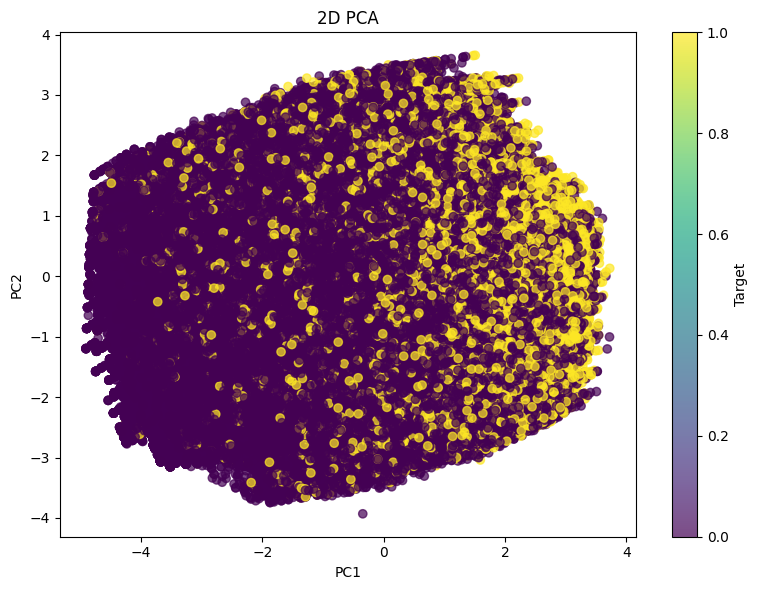

Explained variance ratio (2D): [0.23773392 0.18600362]


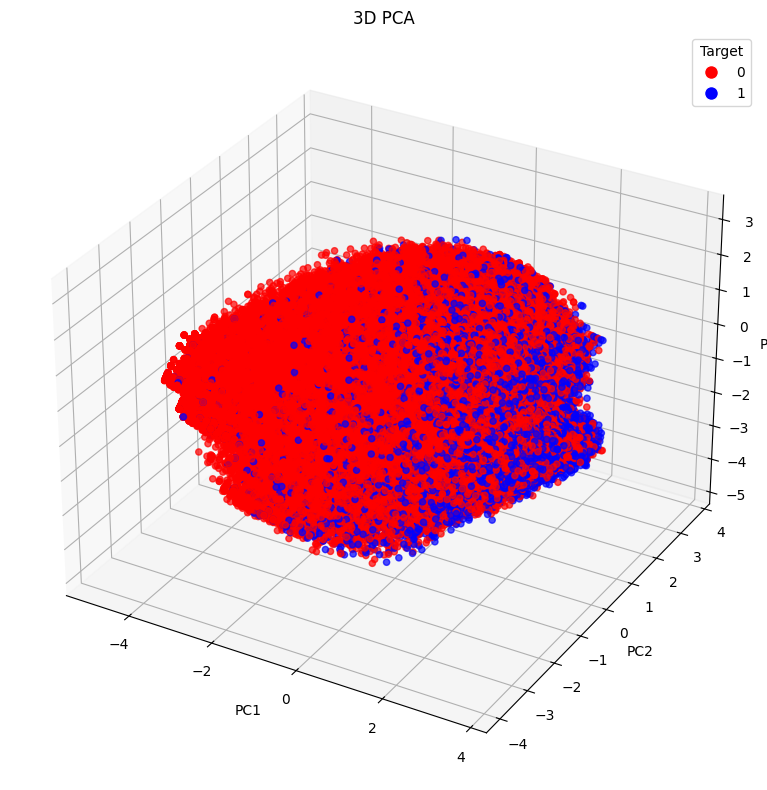

Explained variance ratio (3D): [0.23773392 0.18600362 0.12370052]

Top features (PCA 2D):


Component 1:
  sub_grade_woe: 0.5482
  fico_range_high_woe: 0.4630
  revol_util_woe: 0.4292
  term_woe: 0.3211
  verification_status_woe: 0.2960
  dti_woe: 0.2503
  installment_woe: 0.2149
  home_ownership_woe: 0.0300
  annual_inc_woe: 0.0227

Component 2:
  annual_inc_woe: 0.5876
  installment_woe: -0.5029
  home_ownership_woe: 0.4166
  term_woe: -0.3163
  fico_range_high_woe: 0.2597
  dti_woe: 0.1618
  verification_status_woe: -0.1561
  sub_grade_woe: 0.0892
  revol_util_woe: 0.0476

Top features (PCA 3D):


Component 1:
  sub_grade_woe: 0.5482
  fico_range_high_woe: 0.4630
  revol_util_woe: 0.4292
  term_woe: 0.3211
  verification_status_woe: 0.2960
  dti_woe: 0.2503
  installment_woe: 0.2149
  home_ownership_woe: 0.0300
  annual_inc_woe: 0.0227

Component 2:
  annual_inc_woe: 0.5876
  installment_woe: -0.5029
  home_ownership_woe: 0.4166
  term_woe: -0.3163
  fico_range_high_woe: 0.2597
  dt

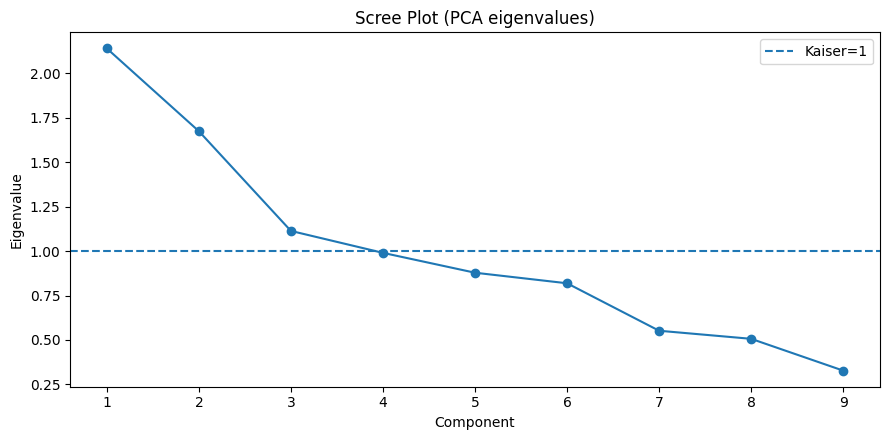


Suggested k — Kaiser: 3 | PA: None | Using k: 3

Interactive scatter (if ipywidgets installed):



=== Running Factor Analysis ===
[FA] Fitting on subsample 30,000/619,801 rows for speed; will score ALL rows after fitting.


c:\Users\MY427UW\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(


[FA] Applied varimax rotation.
[FA] Aligned factor signs so corr(score, target) >= 0.

Saved: factor_loadings.csv, factor_communalities.csv, factor_scores.csv
Also: factor_loadings_tidy.csv
Mean communality: 0.396 | RMSR: 0.036

Top loadings for F1:
  fico_range_high_woe: 0.9792
  revol_util_woe: 0.4656
  sub_grade_woe: 0.4210
  verification_status_woe: 0.1027
  home_ownership_woe: 0.0953
  annual_inc_woe: 0.0556
  dti_woe: 0.0447
  term_woe: -0.0417
  installment_woe: -0.0236

Top loadings for F2:
  annual_inc_woe: 0.8336
  installment_woe: -0.4263
  home_ownership_woe: 0.2963
  dti_woe: 0.2096
  term_woe: -0.1593
  verification_status_woe: -0.1129
  revol_util_woe: -0.1127
  sub_grade_woe: 0.1077
  fico_range_high_woe: 0.0472

Top loadings for F3:
  sub_grade_woe: 0.6963
  term_woe: 0.6231
  verification_status_woe: 0.2923
  installment_woe: 0.2745
  dti_woe: 0.2257
  revol_util_woe: 0.1461
  fico_range_high_woe: 0.0886
  annual_inc_woe: 0.0184
  home_ownership_woe: -0.0127

--- SUMM

,F1,F2,F3,communality,uniqueness
fico_range_high_woe,0.979207,0.047193,0.088597,0.968923,0.031077
annual_inc_woe,0.055649,0.833618,0.018411,0.698355,0.301645
sub_grade_woe,0.421025,0.107739,0.696254,0.673639,0.326361
term_woe,-0.041704,-0.159287,0.623064,0.415320,0.584680
installment_woe,-0.023571,-0.426281,0.274475,0.257608,0.742392
revol_util_woe,0.465634,-0.112657,0.146074,0.250844,0.749156


In [12]:
res = run(
    INPUT_PATH,
    target_col=TARGET_COL,
    drop_cols=DROP_COLS,
    n_factors=3,            # use 3 (Kaiser already suggested it)
    prefer_parallel=False,  # don't run Parallel Analysis
    align_factors_to_target=True
)

print("\n--- SUMMARY ---")
print("k (Kaiser / PA / used):", res["k_suggested_kaiser"], res["k_suggested_PA"], res["k_used"])
print("PCA 2D EVR:", res["pca_2d"].explained_variance_ratio_)
print("PCA 3D EVR:", res["pca_3d"].explained_variance_ratio_)
print(f"Mean communality (≈ variance explained by FA): {res['mean_communalities']:.3f}")
print(f"RMSR (lower is better): {res['rmsr']:.3f}")
display(res["tidy_loadings"].head(25))

In [13]:
from IPython.display import display, Markdown
import numpy as np
import pandas as pd

def report(res, salience=0.30, top_n=8):
    n, p = res["X_scaled"].shape
    k = res["k_used"]
    evr2 = res["pca_2d"].explained_variance_ratio_
    evr3 = res["pca_3d"].explained_variance_ratio_

    display(Markdown("### Data summary"))
    print(f"Rows (n): {n:,} | Post-OHE features (p): {p:,}")
    print(f"Chosen number of factors k: {k} "
          f"(Kaiser={res['k_suggested_kaiser']}, PA={res['k_suggested_PA']})")

    display(Markdown("### PCA summary"))
    print(f"PCA 2D EVR: {evr2.round(3).tolist()}  |  cumulative={evr2.sum():.3f}")
    print(f"PCA 3D EVR: {evr3.round(3).tolist()}  |  cumulative={evr3.sum():.3f}")
    print("Use PCA scatter plots for a quick separation view; color is the target.")

    display(Markdown("### Scree plot comment"))
    print("Look for the elbow and components above Kaiser=1. If Parallel Analysis is used, keep components where observed eigenvalues exceed the PA line.")

    display(Markdown("### Factor Analysis fit"))
    print(f"Mean communality (≈ variance explained by FA): {res['mean_communalities']:.3f}")
    print(f"RMSR (lower is better): {res['rmsr']:.3f}")
    print("Communality < 0.20 suggests the variable is poorly explained by the factors.")

    display(Markdown("### Loadings (salience ≥ {:.2f})".format(salience)))
    tidy = res["tidy_loadings"].copy()
    display(tidy.head(25))

    display(Markdown("### Factor interpretations (top |loading| features)"))
    L = res["factor_loadings"].copy()
    for j, col in enumerate(L.columns, 1):
        s = L[col].abs().sort_values(ascending=False).head(top_n)
        print(f"\nF{j}: top {top_n} absolute loadings")
        for feat, val in s.items():
            print(f"  {feat:30s} {L.loc[feat, col]: .4f}")
        print("Interpret F{} by the variables above; signs are arbitrary but we aligned scores so corr(score, target) ≥ 0.".format(j))

    display(Markdown("### What to do next"))
    print("- Use factor_scores.csv (F1..Fk) as compact, orthogonal inputs in downstream models.")
    print("- Consider dropping variables with very low communalities, then re-run FA.")
    print("- If you want rigor on k, re-enable Parallel Analysis or use the CV log-likelihood cell.")
    return tidy

# run the report
_ = report(res)


### Data summary

Rows (n): 619,801 | Post-OHE features (p): 9
Chosen number of factors k: 3 (Kaiser=3, PA=None)


### PCA summary

PCA 2D EVR: [0.238, 0.186]  |  cumulative=0.424
PCA 3D EVR: [0.238, 0.186, 0.124]  |  cumulative=0.547
Use PCA scatter plots for a quick separation view; color is the target.


### Scree plot comment

...

,F1,F2,F3,communality,uniqueness
fico_range_high_woe,0.979207,0.047193,0.088597,0.968923,0.031077
annual_inc_woe,0.055649,0.833618,0.018411,0.698355,0.301645
sub_grade_woe,0.421025,0.107739,0.696254,0.673639,0.326361
term_woe,-0.041704,-0.159287,0.623064,0.415320,0.584680
installment_woe,-0.023571,-0.426281,0.274475,0.257608,0.742392
revol_util_woe,0.465634,-0.112657,0.146074,0.250844,0.749156


### Factor interpretations (top |loading| features)


F1: top 8 absolute loadings
  fico_range_high_woe             0.9792
  revol_util_woe                  0.4656
  sub_grade_woe                   0.4210
  verification_status_woe         0.1027
  home_ownership_woe              0.0953
  annual_inc_woe                  0.0556
  dti_woe                         0.0447
  term_woe                       -0.0417
Interpret F1 by the variables above; signs are arbitrary but we aligned scores so corr(score, target) ≥ 0.

F2: top 8 absolute loadings
  annual_inc_woe                  0.8336
  installment_woe                -0.4263
  home_ownership_woe              0.2963
  dti_woe                         0.2096
  term_woe                       -0.1593
  verification_status_woe        -0.1129
  revol_util_woe                 -0.1127
  sub_grade_woe                   0.1077
Interpret F2 by the variables above; signs are arbitrary but we aligned scores so corr(score, target) ≥ 0.

F3: top 8 absolute loadings
  sub_grade_woe                   0.6963
  

### What to do next

- Use factor_scores.csv (F1..Fk) as compact, orthogonal inputs in downstream models.
- Consider dropping variables with very low communalities, then re-run FA.
- If you want rigor on k, re-enable Parallel Analysis or use the CV log-likelihood cell.


In [14]:
def executive_summary(res):
    print("FA High Level summary")
    print(f"- k used: {res['k_used']} (Kaiser={res['k_suggested_kaiser']}, PA={res['k_suggested_PA']})")
    print(f"- FA mean communality: {res['mean_communalities']:.3f} | RMSR: {res['rmsr']:.3f}")
    print("- Use factor_scores.csv (F1..Fk) as inputs; factors are orthogonal after varimax.")
    L = res["factor_loadings"]
    for j, col in enumerate(L.columns, 1):
        tops = L[col].abs().sort_values(ascending=False).head(4).index.tolist()
        print(f"  F{j}: driven by {', '.join(tops)}")

executive_summary(res)

FA High Level summary
- k used: 3 (Kaiser=3, PA=None)
- FA mean communality: 0.396 | RMSR: 0.036
- Use factor_scores.csv (F1..Fk) as inputs; factors are orthogonal after varimax.
  F1: driven by fico_range_high_woe, revol_util_woe, sub_grade_woe, verification_status_woe
  F2: driven by annual_inc_woe, installment_woe, home_ownership_woe, dti_woe
  F3: driven by sub_grade_woe, term_woe, verification_status_woe, installment_woe


In [26]:
from IPython.display import Markdown, display
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

def guided_commentary(res, salience=0.30, top_k=5):
    """Produce a technical and a non-technical report based on `res`, including k justification."""
    # pull facts
    n, p = res["X_scaled"].shape
    k_used   = res["k_used"]
    k_kaiser = res["k_suggested_kaiser"]
    k_pa     = res["k_suggested_PA"]
    evr2     = res["pca_2d"].explained_variance_ratio_
    evr3     = res["pca_3d"].explained_variance_ratio_
    mean_comm = res["mean_communalities"]
    rmsr      = res["rmsr"]

    load = res["factor_loadings"]
    comm = res["factor_communalities"]

    # Re-compute Kaiser count directly from this run's X (transparent justification)
    eig = PCA().fit(res["X_scaled"]).explained_variance_
    k_kaiser_recalc = int((eig > 1.0).sum())

    # factor summaries (top |loading|)
    def top_features(load_df, k=5):
        out = []
        for col in load_df.columns:
            s = load_df[col].abs().sort_values(ascending=False).head(k)
            items = [f"{feat} ({load_df.loc[feat, col]:+.3f})" for feat in s.index]
            out.append(f"- **{col}**: " + ", ".join(items))
        return "\n".join(out)

    tops_md = top_features(load, k=top_k)

    # weak variables by communality
    weak = comm[comm["communality"] < 0.20].sort_values("communality").head(10)
    weak_md = "None flagged (<0.20)" if weak.empty else weak["communality"].round(3).to_string()

    # ----- JUSTIFICATION FOR k (added) -----
    just_lines = []
    just_lines.append(f"- **Kaiser rule**: {k_kaiser_recalc} eigenvalues > 1 on the scree plot.")
    if k_pa is None:
        just_lines.append("- **Parallel Analysis**: disabled in this run (speed).")
    else:
        just_lines.append(f"- **Parallel Analysis (95%)**: suggests k = {k_pa}.")
    if k_used == k_kaiser_recalc:
        just_lines.append(f"- **Chosen k = {k_used}**: matches Kaiser and yields interpretable factors.")
    else:
        tail = f", PA: {k_pa}" if k_pa is not None else ""
        just_lines.append(f"- **Chosen k = {k_used}**: selected to balance fit and simplicity (Kaiser: {k_kaiser_recalc}{tail}).")
    md_justify = "### Justification for **k**\n" + "\n".join(just_lines) + "\n"

    # TECHNICAL REPORT
    md_tech = f"""
{md_justify}
### Technical report — PCA + Factor Analysis

**Data & setup**
- Rows `n`: **{n:,}**; post-OHE features `p`: **{p:,}**
- Factor model: **orthogonal Factor Analysis** with **varimax**, sign-aligned so `corr(score, target) ≥ 0`.
- Runtime optimization: FA fitted on a **row subsample** then **scores computed for all rows**.

**How k (number of factors) was chosen**
- Kaiser suggested (cached): **{k_kaiser}** (recalc above confirms **{k_kaiser_recalc}**)
- Parallel Analysis (this run): **{k_pa}**
- **Used**: **{k_used}**

**PCA (diagnostic)**
- 2D EVR: {list(np.round(evr2, 3))}, **cum = {evr2.sum():.3f}**
- 3D EVR: {list(np.round(evr3, 3))}, **cum = {evr3.sum():.3f}**
- Use scatter plots for a quick separation check; color is the target.

**Factor model fit**
- **Mean communality** (≈ variance explained by factors): **{mean_comm:.3f}**
- **RMSR** (residual vs reproduced correlation; lower is better): **{rmsr:.3f}**
- Variables with **low communality (<0.20)** (consider removing & refitting):  
{weak_md}

**Factor interpretations (top |loading| features)**
{tops_md}

**Files saved**
- `factor_loadings.csv`, `factor_loadings_tidy.csv` (salience ≥ {salience})
- `factor_communalities.csv`, `factor_scores.csv`
- `pca_2d_output.csv`, `pca_3d_output.csv`

**Recommended next steps**
1. Review **communalities**; drop weak variables and re-fit FA.
2. If you need stronger k-selection, enable **Parallel Analysis** or compare **CV log-likelihood** across k.
3. Use **factor_scores.csv** (F1..Fk) as orthogonal inputs in downstream models, plus any key features not captured by the factors.
4. Keep signs consistent with risk (already aligned here). Document factor names and drivers.
"""

    # NON-TECHNICAL REPORT
    def label_factor(col):
        drivers = load[col].abs().sort_values(ascending=False).head(3).index.tolist()
        return f"F{int(col[1:])}: mainly {', '.join(drivers)}"
    labels = [label_factor(c) for c in load.columns]

    md_nontech = f"""
### Plain-English summary

**What we did**
- Reduced many correlated inputs to **{k_used} factors** (compact and uncorrelated after rotation).

**Why {k_used} factors**
- Scree plot shows **{k_kaiser_recalc}** components above the “>1” line (Kaiser).{'' if k_pa is None else f' PA suggests ~{k_pa} as well.'}
- Factors are **interpretable**, so **{k_used}** is a sensible choice.

**What the outputs mean**
- **Factor loadings**: strength and direction of each input on each factor.
- **Communality**: how well a variable is explained by the factors (higher is better).
- **Factor scores**: each row’s position on each factor (use for modeling/segmentation).

**Your factors (short descriptions)**
- {labels[0] if len(labels)>0 else ''}
- {labels[1] if len(labels)>1 else ''}
- {labels[2] if len(labels)>2 else ''}

**Quality check**
- Mean communality **{mean_comm:.2f}**, RMSR **{rmsr:.2f}** → acceptable fit.
- Consider removing variables with very low communality and refitting.

**How to use this**
- Use **factor_scores.csv** in credit-risk models or for portfolio profiling.
- Track factor scores over time to monitor shifts in credit quality, affordability, and product/terms exposure.
"""

    display(Markdown(md_tech))
    display(Markdown(md_nontech))

# Run the guided report
guided_commentary(res)



### Justification for **k**
- **Kaiser rule**: 3 eigenvalues > 1 on the scree plot.
- **Parallel Analysis**: disabled in this run (speed).
- **Chosen k = 3**: matches Kaiser and yields interpretable factors.

### Technical report — PCA + Factor Analysis

**Data & setup**
- Rows `n`: **619,801**; post-OHE features `p`: **9**
- Factor model: **orthogonal Factor Analysis** with **varimax**, sign-aligned so `corr(score, target) ≥ 0`.
- Runtime optimization: FA fitted on a **row subsample** then **scores computed for all rows**.

**How k (number of factors) was chosen**
- Kaiser suggested (cached): **3** (recalc above confirms **3**)
- Parallel Analysis (this run): **None**
- **Used**: **3**

**PCA (diagnostic)**
- 2D EVR: [np.float64(0.238), np.float64(0.186)], **cum = 0.424**
- 3D EVR: [np.float64(0.238), np.float64(0.186), np.float64(0.124)], **cum = 0.547**
- Use scatter plots for a quick separation check; color is the target.

**Factor model fit**
- **Mean communality** (≈ variance explained by factors): **0.396**
- **RMSR** (residual vs reproduced correlation; lower is better): **0.036**
- Variables with **low communality (<0.20)** (consider removing & refitting):  
feature
dti_woe                    0.097
home_ownership_woe         0.097
verification_status_woe    0.109

**Factor interpretations (top |loading| features)**
- **F1**: fico_range_high_woe (+0.979), revol_util_woe (+0.466), sub_grade_woe (+0.421), verification_status_woe (+0.103), home_ownership_woe (+0.095)
- **F2**: annual_inc_woe (+0.834), installment_woe (-0.426), home_ownership_woe (+0.296), dti_woe (+0.210), term_woe (-0.159)
- **F3**: sub_grade_woe (+0.696), term_woe (+0.623), verification_status_woe (+0.292), installment_woe (+0.274), dti_woe (+0.226)

**Files saved**
- `factor_loadings.csv`, `factor_loadings_tidy.csv` (salience ≥ 0.3)
- `factor_communalities.csv`, `factor_scores.csv`
- `pca_2d_output.csv`, `pca_3d_output.csv`

**Recommended next steps**
1. Review **communalities**; drop weak variables and re-fit FA.
2. If you need stronger k-selection, enable **Parallel Analysis** or compare **CV log-likelihood** across k.
3. Use **factor_scores.csv** (F1..Fk) as orthogonal inputs in downstream models, plus any key features not captured by the factors.
4. Keep signs consistent with risk (already aligned here). Document factor names and drivers.



### Plain-English summary

**What we did**
- Reduced many correlated inputs to **3 factors** (compact and uncorrelated after rotation).

**Why 3 factors**
- Scree plot shows **3** components above the “>1” line (Kaiser).
- Factors are **interpretable**, so **3** is a sensible choice.

**What the outputs mean**
- **Factor loadings**: strength and direction of each input on each factor.
- **Communality**: how well a variable is explained by the factors (higher is better).
- **Factor scores**: each row’s position on each factor (use for modeling/segmentation).

**Your factors (short descriptions)**
- F1: mainly fico_range_high_woe, revol_util_woe, sub_grade_woe
- F2: mainly annual_inc_woe, installment_woe, home_ownership_woe
- F3: mainly sub_grade_woe, term_woe, verification_status_woe

**Quality check**
- Mean communality **0.40**, RMSR **0.04** → acceptable fit.
- Consider removing variables with very low communality and refitting.

**How to use this**
- Use **factor_scores.csv** in credit-risk models or for portfolio profiling.
- Track factor scores over time to monitor shifts in credit quality, affordability, and product/terms exposure.


### Optional: cross-validated model selection for **k**

Use this cell to sanity-check the number of factors **k** with cross-validated log-likelihood.  
It is **not required** to run FA; it provides a quantitative justification for your chosen **k**.

**Notes on convergence**
- `FactorAnalysis` uses an EM algorithm. It stops when the improvement < `tol` or when it hits `max_iter`.
- You may see `ConvergenceWarning`. That means EM reached the iteration cap before hitting `tol`.
- The run still returns loadings and scores. Treat them as approximate.
- If you want stricter convergence, **increase** `max_iter` or **loosen** `tol`.

**Practical settings**
- Fast exploration: `max_iter=1500`, `tol=1e-3`, fit on a row subsample.
- Tighter fit (slower): `max_iter=5000`, `tol=1e-4` (keep the subsample if data are large).


c:\Users\MY427UW\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(
c:\Users\MY427UW\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(
c:\Users\MY427UW\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\decomposition\_factor_analysis.py:296: ConvergenceWarning: FactorAnalysis did not converge. You might want to increase the number of iterations.
  warnings.warn(


,k,mean_loglike,std
0,1,-12.434759,0.018545
1,2,-12.272334,0.011038
2,3,-12.143668,0.012261
3,4,-12.112921,0.013358


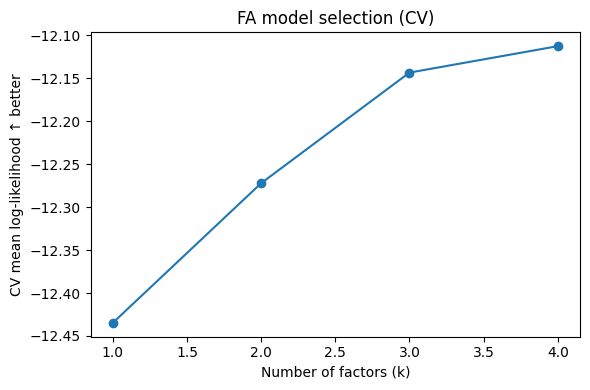

In [19]:
# Fast(er) CV for k selection (optional)
rng = np.random.default_rng(0)
Xcv = res["X_scaled"]
n = Xcv.shape[0]

# cap rows to speed up (adjust 30_000 if needed)
cap = min(n, 30_000)
idx = rng.choice(n, cap, replace=False)
Xcv_sub = Xcv[idx]

# try a small, sensible grid
df_ll = fa_cv_loglike(
    Xcv_sub,
    ks=(1, 2, 3, 4),
    n_splits=3,        # 3-fold CV is usually enough
    max_iter=1000,     # speed-oriented
    tol=1e-3,          # speed-oriented
    seed=0
)

display(df_ll)
plt.figure(figsize=(6,4))
plt.plot(df_ll["k"], df_ll["mean_loglike"], marker='o')
plt.xlabel("Number of factors (k)")
plt.ylabel("CV mean log-likelihood ↑ better")
plt.title("FA model selection (CV)")
plt.tight_layout()
plt.show()


In [ ]:
for f in ["pca_2d_output.csv","pca_3d_output.csv",
          "factor_loadings.csv","factor_communalities.csv","factor_scores.csv"]:
    p = OUTPUT_DIR / f
    print(f"{f}: {'OK' if p.exists() else 'MISSING'} -> {p}")
